# Notebook 02 - Blur Detection

**Method:** Laplacian Variance

**How it works:**
1. Convert image to grayscale
2. Apply Laplacian filter (detects edges / high-frequency content)
3. Compute variance of the result
4. **Low variance → few edges → blurry image**

**Threshold:** Score < 100 = blurry

**Speed:** ~5ms per image on CPU

**Research:** PyImageSearch "Blur Detection with OpenCV" (2015)

In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.blur   import compute_blur_score, is_blurry, get_blur_label
from src.config import DATASET_ROOT, IMAGE_EXTENSIONS, BLUR_THRESHOLD

## 1. Understand the Laplacian Filter

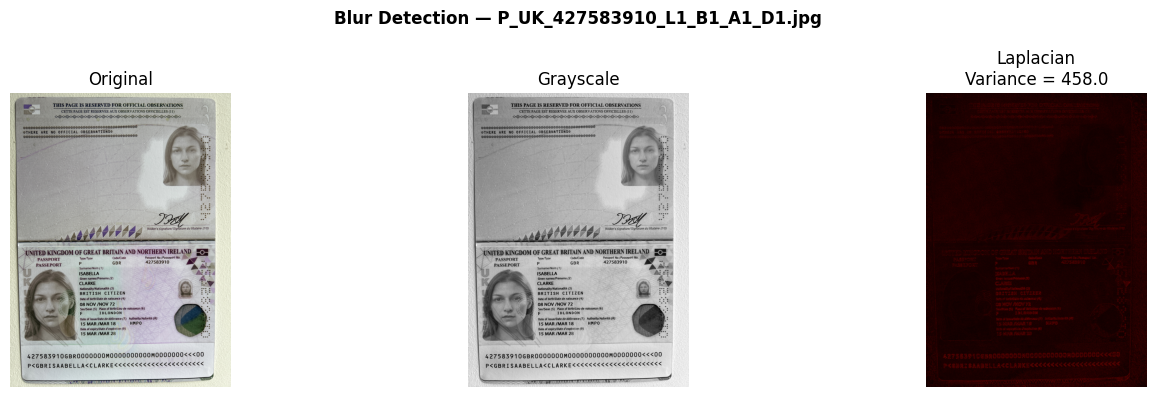

In [2]:
# Load one sample image
all_images = [p for p in Path(DATASET_ROOT).rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS]
img_path   = all_images[0]

img  = cv2.imread(str(img_path))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Laplacian
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
score     = laplacian.var()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[2].imshow(np.abs(laplacian), cmap='hot')
axes[2].set_title(f'Laplacian\nVariance = {score:.1f}')

for ax in axes: ax.axis('off')
plt.suptitle(f'Blur Detection — {img_path.name}', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Scan All Images - Blur Score Distribution

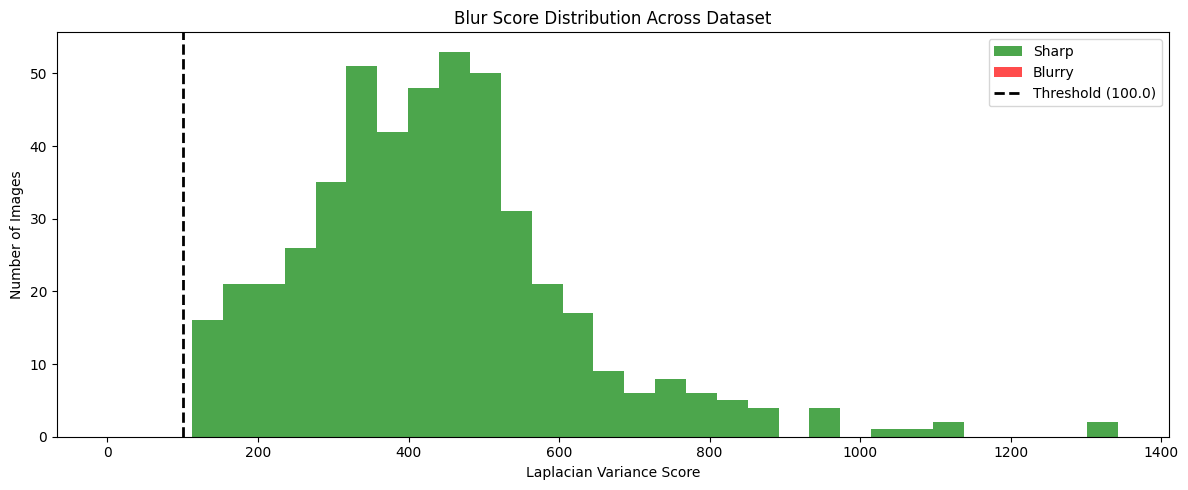

Sharp:  480 images (100%)
Blurry: 0 images (0%)


In [3]:
scores = []
labels = []

for img_path in all_images:
    img  = cv2.imread(str(img_path))
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    score, blurry = is_blurry(gray)
    scores.append(score)
    labels.append('Blurry' if blurry else 'Sharp')

sharp_scores  = [s for s, l in zip(scores, labels) if l == 'Sharp']
blurry_scores = [s for s, l in zip(scores, labels) if l == 'Blurry']

plt.figure(figsize=(12, 5))
plt.hist(sharp_scores,  bins=30, alpha=0.7, color='green', label='Sharp')
plt.hist(blurry_scores, bins=30, alpha=0.7, color='red',   label='Blurry')
plt.axvline(BLUR_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold ({BLUR_THRESHOLD})')
plt.xlabel('Laplacian Variance Score')
plt.ylabel('Number of Images')
plt.title('Blur Score Distribution Across Dataset')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Sharp:  {len(sharp_scores)} images ({100*len(sharp_scores)//len(scores)}%)')
print(f'Blurry: {len(blurry_scores)} images ({100*len(blurry_scores)//len(scores)}%)')

## 3. Which Lighting Condition Causes Most Blur?

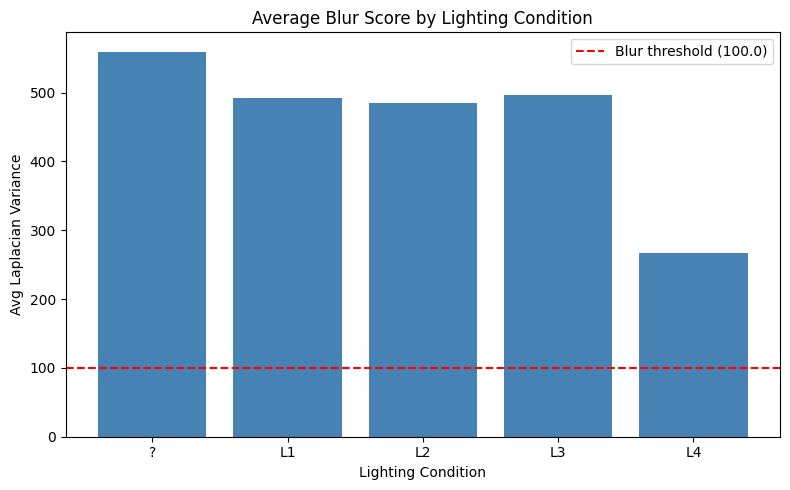

In [4]:
from collections import defaultdict
from src.parser import parse_filename

lighting_scores = defaultdict(list)

for img_path in all_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    score = compute_blur_score(gray)
    meta  = parse_filename(img_path.name)
    lighting_scores[meta['lighting']].append(score)

avg_by_lighting = {k: np.mean(v) for k, v in sorted(lighting_scores.items())}

plt.figure(figsize=(8, 5))
plt.bar(avg_by_lighting.keys(), avg_by_lighting.values(), color='steelblue')
plt.axhline(BLUR_THRESHOLD, color='red', linestyle='--', label=f'Blur threshold ({BLUR_THRESHOLD})')
plt.xlabel('Lighting Condition')
plt.ylabel('Avg Laplacian Variance')
plt.title('Average Blur Score by Lighting Condition')
plt.legend()
plt.tight_layout()
plt.show()